In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
import torchvision.transforms.v2 as v2
import os
import pickle
import json
from datetime import datetime

from datasets import load_dataset
from torchvision.transforms import (
    Compose, Normalize, RandomHorizontalFlip, RandomVerticalFlip,
    RandomResizedCrop, Resize, CenterCrop, ToTensor, RandomRotation
)
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, f1_score
from tqdm import tqdm

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cpu


In [ ]:
# ─── Configuración ───────────────────────────────────────────────────────────
NUM_EPOCHS       = 100        # Épocas de entrenamiento
BATCH_SIZE       = 32        # Tamaño de batch
LR_HEAD          = 1e-3      # Learning rate para la cabeza (capas nuevas)
LR_BACKBONE      = 1e-4      # Learning rate para el backbone (capas pre-entrenadas)
WEIGHT_DECAY     = 1e-4      # Regularización L2
IMG_SIZE         = 300       # Tamaño de entrada a ResNet
UNFREEZE_EPOCH   = 4         # Época en la que se descongela el backbone
# ─────────────────────────────────────────────────────────────────────────────

print('Hiperparámetros cargados correctamente.')

Hiperparámetros cargados correctamente.


In [ ]:
# ─── Load the dataset from Hugging Face ─────────────────────────────────────
print("Loading dataset from Hugging Face...")

raw = load_dataset(
    "Atoany/ISIC2019",
    #token=""
)

labels = raw['train'].unique('label')
id2label = {k: v for k, v in enumerate(labels)}
label2id = {v: k for k, v in enumerate(labels)}
NUM_CLASSES = len(labels)

print(f'Clases ({NUM_CLASSES}): {labels}')
print(f'Splits disponibles: {list(raw.keys())}')
print(f'Ejemplos en train: {len(raw["train"])}')
if 'test' in raw:
    print(f'Ejemplos en test:  {len(raw["test"])}')

# ─── FIXED SPLITS (to avoid leakage across different model runs) ─────────────
split_file = 'isic2019_fixed_splits.pkl'

if os.path.exists(split_file):
    print(f"✅ Loading fixed splits from {split_file}...")
    with open(split_file, 'rb') as f:
        splits = pickle.load(f)
    
    train_hf = splits['train']
    val_hf   = splits['val']
    test_hf  = splits['test']
    
else:
    print("🔄 Creating new fixed splits (this will only happen once)...")
    
    # Your original splitting logic, but now saved
    if 'validation' not in raw and 'test' not in raw:
        # Only 'train' exists → split into train/val/test (80/10/10)
        split_tv = raw['train'].train_test_split(test_size=0.2, seed=SEED)
        split_vt = split_tv['test'].train_test_split(test_size=0.5, seed=SEED)
        
        train_hf = split_tv['train']
        val_hf   = split_vt['train']
        test_hf  = split_vt['test']
        
    elif 'validation' in raw and 'test' not in raw:
        train_hf = raw['train']
        split_vt = raw['validation'].train_test_split(test_size=0.5, seed=SEED)
        val_hf   = split_vt['train']
        test_hf  = split_vt['test']
        
    elif 'validation' not in raw and 'test' in raw:
        split_tv = raw['train'].train_test_split(test_size=0.2, seed=SEED)
        train_hf = split_tv['train']
        val_hf   = split_tv['test']
        test_hf  = raw['test']
        
    else:
        # All splits already exist
        train_hf = raw['train']
        val_hf   = raw['validation']
        test_hf  = raw['test']

    # Save the splits for future runs (this prevents leakage)
    splits = {'train': train_hf, 'val': val_hf, 'test': test_hf}
    with open(split_file, 'wb') as f:
        pickle.dump(splits, f)
    
    print(f"✅ Fixed splits created and saved to '{split_file}'")

# Print final split sizes
print(f'Train:      {len(train_hf):>6} muestras')
print(f'Validation: {len(val_hf):>6} muestras')
print(f'Test:       {len(test_hf):>6} muestras')

Loading dataset from Hugging Face...
Clases (8): ['MEL', 'NV', 'AK', 'BCC', 'BKL', 'VASC', 'DF', 'SCC']
Splits disponibles: ['train', 'test']
Ejemplos en train: 20264
Ejemplos en test:  5067
✅ Loading fixed splits from isic2019_fixed_splits.pkl...
Train:       16211 muestras
Validation:   4053 muestras
Test:         5067 muestras


In [25]:
import os
from collections import defaultdict

def save_3_per_class(dataset, id2label, output_dir="class_samples", n=3):

    os.makedirs(output_dir, exist_ok=True)

    counts = defaultdict(int)

    num_classes = len(id2label)

    print("Dataset size:", len(dataset))

    for i in range(len(dataset)):

        sample = dataset[i]

        label = sample["label"]
        img = sample["image"]

        label_name = id2label[label] if isinstance(label, int) else str(label)

        if counts[label_name] < n:

            class_dir = os.path.join(output_dir, label_name)
            os.makedirs(class_dir, exist_ok=True)

            path = os.path.join(class_dir, f"{label_name}_{counts[label_name]}.jpg")

            img.save(path)

            counts[label_name] += 1

        # 🚀 STOP CONDITION
        if len(counts) == num_classes and all(v >= n for v in counts.values()):
            print("All classes complete. Stopping early.")
            break

    print("Done. Saved samples per class:")
    print(dict(counts))

save_3_per_class(train_hf, id2label)

Dataset size: 16211
All classes complete. Stopping early.
Done. Saved samples per class:
{'BKL': 3, 'BCC': 3, 'MEL': 3, 'NV': 3, 'AK': 3, 'DF': 3, 'SCC': 3, 'VASC': 3}


In [4]:
# Estadísticas de normalización de ImageNet (las usa ResNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transformaciones para entrenamiento (con data augmentation)
train_transforms = Compose([
    RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    RandomRotation(degrees=15),
    RandomHorizontalFlip(p=0.5),
    RandomVerticalFlip(p=0.3),
    ToTensor(),
    Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = Compose([
    Resize(IMG_SIZE + 32),      # e.g., 332 for 300 input
    CenterCrop(IMG_SIZE),
    ToTensor(),
    Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class ISICDataset(Dataset):
    """Dataset wrapper para ISIC2019 con transformaciones de PyTorch."""

    def __init__(self, hf_dataset, transform=None):
        self.data      = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image  = sample['image'].convert('RGB')   # Asegurar 3 canales
        label  = label2id[sample['label']]

        if self.transform:
            image = self.transform(image)

        return image, label


print('Transformaciones y clase Dataset definidas correctamente.')

Transformaciones y clase Dataset definidas correctamente.


In [5]:
# Separar splits
# Si el dataset solo tiene 'train', dividimos manualmente (80/10/10)
if 'validation' not in raw and 'test' not in raw:
    split_tv  = raw['train'].train_test_split(test_size=0.2, seed=SEED)
    split_vt  = split_tv['test'].train_test_split(test_size=0.5, seed=SEED)
    train_hf  = split_tv['train']
    val_hf    = split_vt['train']
    test_hf   = split_vt['test']
# Si 'train' y 'validation' están presentes, pero no 'test'
elif 'validation' in raw and 'test' not in raw:
    train_hf  = raw['train']
    split_vt  = raw['validation'].train_test_split(test_size=0.5, seed=SEED)
    val_hf    = split_vt['train']
    test_hf   = split_vt['test']
# Si 'train' y 'test' están presentes, pero no 'validation'
elif 'validation' not in raw and 'test' in raw:
    # Dividir 'train' en train y validation, usar 'test' existente para test
    split_tv = raw['train'].train_test_split(test_size=0.2, seed=SEED) # 80% train, 20% validation
    train_hf = split_tv['train']
    val_hf   = split_tv['test']
    test_hf  = raw['test']
# Si todas las divisiones ('train', 'validation', 'test') están presentes
else:
    train_hf  = raw['train']
    val_hf    = raw['validation']
    test_hf   = raw['test']

print(f'Train:      {len(train_hf):>6} muestras')
print(f'Validation: {len(val_hf):>6} muestras')
print(f'Test:       {len(test_hf):>6} muestras')

# Instanciar Dataset
train_dataset = ISICDataset(train_hf, transform=train_transforms)
val_dataset   = ISICDataset(val_hf,   transform=val_transforms)
test_dataset  = ISICDataset(test_hf,  transform=val_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                           pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                           pin_memory=True)

print('DataLoaders creados correctamente.')

Train:       16211 muestras
Validation:   4053 muestras
Test:         5067 muestras
DataLoaders creados correctamente.


In [6]:
def build_model(num_classes: int, freeze_backbone: bool = True):
    """
    Construye EfficientNet-B3 (o B4) pre-entrenado y reemplaza la cabeza.
    """
    # === Choose your variant here ===
    model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
    # model = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)  # Better but slower

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # EfficientNet has 'classifier' instead of 'fc'
    in_features = model.classifier[1].in_features   # 1536 for B3, 1792 for B4

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )
    
    return model


def unfreeze_backbone(model, optimizer):
    """Descongela el backbone y actualiza el optimizador."""
    for param in model.parameters():
        param.requires_grad = True

    # Backbone = todo excepto la cabeza classifier
    backbone_params = [p for name, p in model.named_parameters() 
                       if not name.startswith('classifier')]
    head_params     = list(model.classifier.parameters())

    optimizer.param_groups.clear()
    optimizer.add_param_group({'params': backbone_params, 'lr': LR_BACKBONE})
    optimizer.add_param_group({'params': head_params,     'lr': LR_HEAD})
    
    print('  → Backbone de EfficientNet descongelado con LR diferenciado.')


# Construir modelo
model = build_model(NUM_CLASSES, freeze_backbone=True).to(device)

# Contar parámetros
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros totales:     {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)')

Parámetros totales:     11,487,280
Parámetros entrenables: 791,048 (6.9%)


In [7]:
# ── Pérdida con pesos de clase para combatir el desbalance ───────────────────
from collections import Counter

class_counts = Counter(train_hf['label'])
total        = sum(class_counts.values())
class_weights = torch.tensor(
    [total / (NUM_CLASSES * class_counts[id2label[i]]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss()

# ── Optimizador (solo cabeza al inicio) ──────────────────────────────────────
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

# ── Learning rate scheduler — cosine annealing ───────────────────────────────
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print('Criterio, optimizador y scheduler configurados.')
print(f'Pesos de clase: {class_weights.cpu().numpy().round(3)}')

Criterio, optimizador y scheduler configurados.
Pesos de clase: [ 0.712  0.246  3.788  0.936  1.188 12.907 12.665  4.991]


In [8]:
# ─── MixUp + CutMix Random Choice (Recommended for ISIC 2019) ───────────────
mix_transform = v2.RandomChoice([
    v2.MixUp(alpha=0.3, num_classes=NUM_CLASSES),      # Slightly lower alpha
    v2.CutMix(alpha=1.0, num_classes=NUM_CLASSES)      # CutMix usually uses higher alpha
])

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, leave=False, desc='  Train'):
        images, labels = images.to(device), labels.to(device)

        # Randomly apply MixUp or CutMix
        images, soft_labels = mix_transform(images, labels)   # ← This is the main change

        optimizer.zero_grad()
        outputs = model(images)
        
        # Loss with soft labels from MixUp/CutMix
        loss = criterion(outputs, soft_labels)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        
        # Accuracy approximation (standard practice)
        preds = outputs.argmax(dim=1)
        hard_labels = soft_labels.argmax(dim=1)
        correct += (preds == hard_labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, leave=False, desc='  Eval '):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


print('Funciones de entrenamiento y evaluación definidas.')

Funciones de entrenamiento y evaluación definidas.


In [ ]:
# ─── Setup for logging and saving ───────────────────────────────────────────
log_dir = "training_logs"
os.makedirs(log_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = "efficientnet_b3_300"

# Define best model path automatically
best_model_path = f'{model_name}_best.pth'

history_file = os.path.join(log_dir, f'history_{model_name}_{timestamp}.json')

print(f"💾 Best model will be saved as: {best_model_path}")
print(f"📈 Training history will be saved to: {history_file}\n")

# ─── Training Loop ─────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
epochs_no_improve = 0
patience = 10

for epoch in range(1, NUM_EPOCHS + 1):

    # Unfreeze backbone
    if epoch == UNFREEZE_EPOCH + 1:
        print(f'\nÉpoca {epoch}: Descongelando backbone...')
        unfreeze_backbone(model, optimizer)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - UNFREEZE_EPOCH, eta_min=1e-6
        )
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Parámetros entrenables: {trainable:,}')

    # Training + Validation
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step()

    # Save best model
    if val_acc > best_val_acc + 1e-4:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
        ckpt_msg = '  ✔ Best'
    else:
        epochs_no_improve += 1
        ckpt_msg = ''

    # Store in history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    lr_now = optimizer.param_groups[-1]['lr']

    # Console output
    print(f'Época {epoch:>3}/{NUM_EPOCHS} | '
          f'Loss: {train_loss:.4f} / {val_loss:.4f} | '
          f'Acc: {train_acc:.4f} / {val_acc:.4f} | '
          f'LR: {lr_now:.2e}{ckpt_msg}')

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

# ─── Save history to JSON ───────────────────────────────────────────────────
final_history = {
    "train_loss": history['train_loss'],
    "val_loss": history['val_loss'],
    "train_acc": history['train_acc'],
    "val_acc": history['val_acc'],
    "best_val_acc": float(best_val_acc),
    "total_epochs": int(epoch),
    "early_stopped": epochs_no_improve >= patience,
    "model_name": model_name,
    "img_size": int(IMG_SIZE),
    "seed": int(SEED),
    "timestamp": timestamp,
    "best_model_path": best_model_path
}

with open(history_file, 'w', encoding='utf-8') as f:
    json.dump(final_history, f, indent=4)

print(f"\n✅ Entrenamiento finalizado. Mejor val acc: {best_val_acc:.4f}")
print(f"💾 Best model saved as: {best_model_path}")
print(f"📈 History saved to: {history_file}")

💾 Best model will be saved as: efficientnet_b3_300_best.pth
📈 Training history will be saved to: training_logs\history_efficientnet_b3_300_20260418_120110.json



Época   1/100 | Loss: 1.2633 / 1.0262 | Acc: 0.5751 / 0.6546 | LR: 1.00e-03  ✔ Best


Época   2/100 | Loss: 1.2032 / 0.9842 | Acc: 0.5935 / 0.6440 | LR: 9.99e-04


Época   3/100 | Loss: 1.1953 / 0.9686 | Acc: 0.5951 / 0.6524 | LR: 9.98e-04


Época   4/100 | Loss: 1.1835 / 0.9684 | Acc: 0.6020 / 0.6721 | LR: 9.96e-04  ✔ Best

Época 5: Descongelando backbone...
  → Backbone de EfficientNet descongelado con LR diferenciado.
  Parámetros entrenables: 11,487,280


...

Época  85/100 | Loss: 0.4875 / 0.3751 | Acc: 0.9149 / 0.8885 | LR: 6.00e-05


Época  86/100 | Loss: 0.4866 / 0.3684 | Acc: 0.9173 / 0.8890 | LR: 5.25e-05


Época  87/100 | Loss: 0.5026 / 0.3690 | Acc: 0.9035 / 0.8875 | LR: 4.55e-05


Época  88/100 | Loss: 0.4832 / 0.3708 | Acc: 0.9143 / 0.8877 | LR: 3.90e-05


Época  89/100 | Loss: 0.4791 / 0.3721 | Acc: 0.9156 / 0.8909 | LR: 3.30e-05

Early stopping triggered at epoch 89

✅ Entrenamiento finalizado. Mejor val acc: 0.8927
💾 Best model saved as: efficientnet_b3_300_best.pth
📈 History saved to: training_logs\history_efficientnet_b3_300_20260418_120110.json


Loaded history for: efficientnet_b3_300
Best Validation Accuracy: 0.8927
Total epochs trained: 89


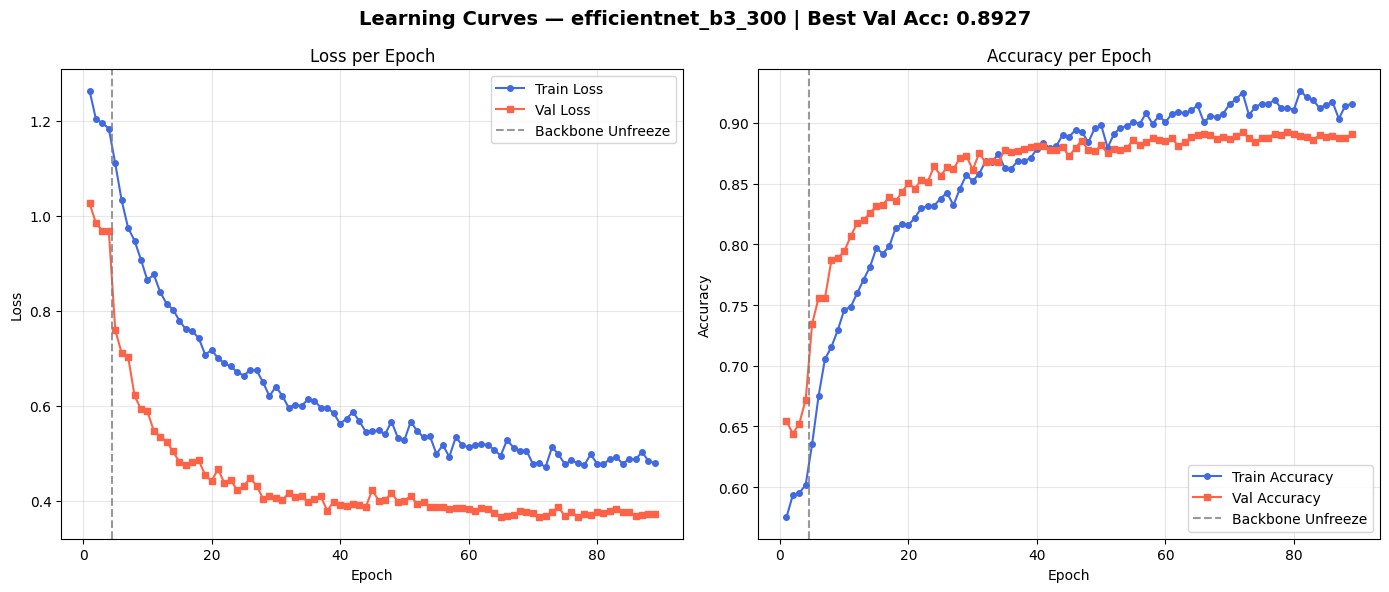

In [ ]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

history_path = "cnn/training_logs/history_efficientnet_b3_300_20260418_120110.json"   # ←←← UPDATE THIS

with open(history_path, 'r', encoding='utf-8') as f:
    h = json.load(f)

train_loss = h['train_loss']
val_loss   = h['val_loss']
train_acc  = h['train_acc']
val_acc    = h['val_acc']

epochs_range = range(1, len(train_loss) + 1)

model_name = h.get('model_name', 'Model')
best_val_acc = h.get('best_val_acc', 0.0)
unfreeze_epoch = UNFREEZE_EPOCH if 'UNFREEZE_EPOCH' in globals() else 3 

print(f"Loaded history for: {model_name}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Total epochs trained: {len(train_loss)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(epochs_range, train_loss, 'o-', label='Train Loss', color='royalblue', markersize=4)
axes[0].plot(epochs_range, val_loss,   's-', label='Val Loss',   color='tomato', markersize=4)
if unfreeze_epoch is not None:
    axes[0].axvline(unfreeze_epoch + 0.5, color='gray', linestyle='--', alpha=0.8, label='Backbone Unfreeze')

axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_acc, 'o-', label='Train Accuracy', color='royalblue', markersize=4)
axes[1].plot(epochs_range, val_acc,   's-', label='Val Accuracy',   color='tomato', markersize=4)
if unfreeze_epoch is not None:
    axes[1].axvline(unfreeze_epoch + 0.5, color='gray', linestyle='--', alpha=0.8, label='Backbone Unfreeze')

axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'Learning Curves — {model_name} | Best Val Acc: {best_val_acc:.4f}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ====================== FINAL TEST EVALUATION =====================
print(f"Loading best model: {best_model_path}")
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating Test Set'):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
test_acc = (all_preds == all_labels).mean()

print("\n" + "="*75)
print(f"TEST EVALUATION — {best_model_path}")
print("="*75)
print(f"Raw Accuracy        : {test_acc:.4f}  ({test_acc*100:.2f}%)")

# Classification Report (Safe version)
unique_classes = sorted(set(all_labels))

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    labels=unique_classes,
    target_names=[id2label[i] for i in unique_classes],
    digits=4,
    zero_division=0
))

balanced_acc = balanced_accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print("-" * 75)
print(f"Balanced Accuracy   : {balanced_acc:.4f}")
print(f"Macro F1 Score      : {macro_f1:.4f}")
print("=" * 75)

Loading best model: efficientnet_b3_300_best.pth


Evaluating Test Set: 100%|██████████| 159/159 [00:48<00:00,  3.28it/s]


TEST EVALUATION — efficientnet_b3_300_best.pth
Raw Accuracy        : 0.8968  (89.68%)

Classification Report:
              precision    recall  f1-score   support

         MEL     0.8812    0.8051    0.8414       949
          NV     0.9232    0.9551    0.9389      2606
          AK     0.8375    0.7363    0.7836       182
         BCC     0.8935    0.9274    0.9101       606
         BKL     0.8421    0.8205    0.8312       507
        VASC     0.9464    0.9138    0.9298        58
          DF     0.9024    0.8810    0.8916        42
         SCC     0.7177    0.7607    0.7386       117

    accuracy                         0.8968      5067
   macro avg     0.8680    0.8500    0.8581      5067
weighted avg     0.8959    0.8968    0.8957      5067

---------------------------------------------------------------------------
Balanced Accuracy   : 0.8500
Macro F1 Score      : 0.8581


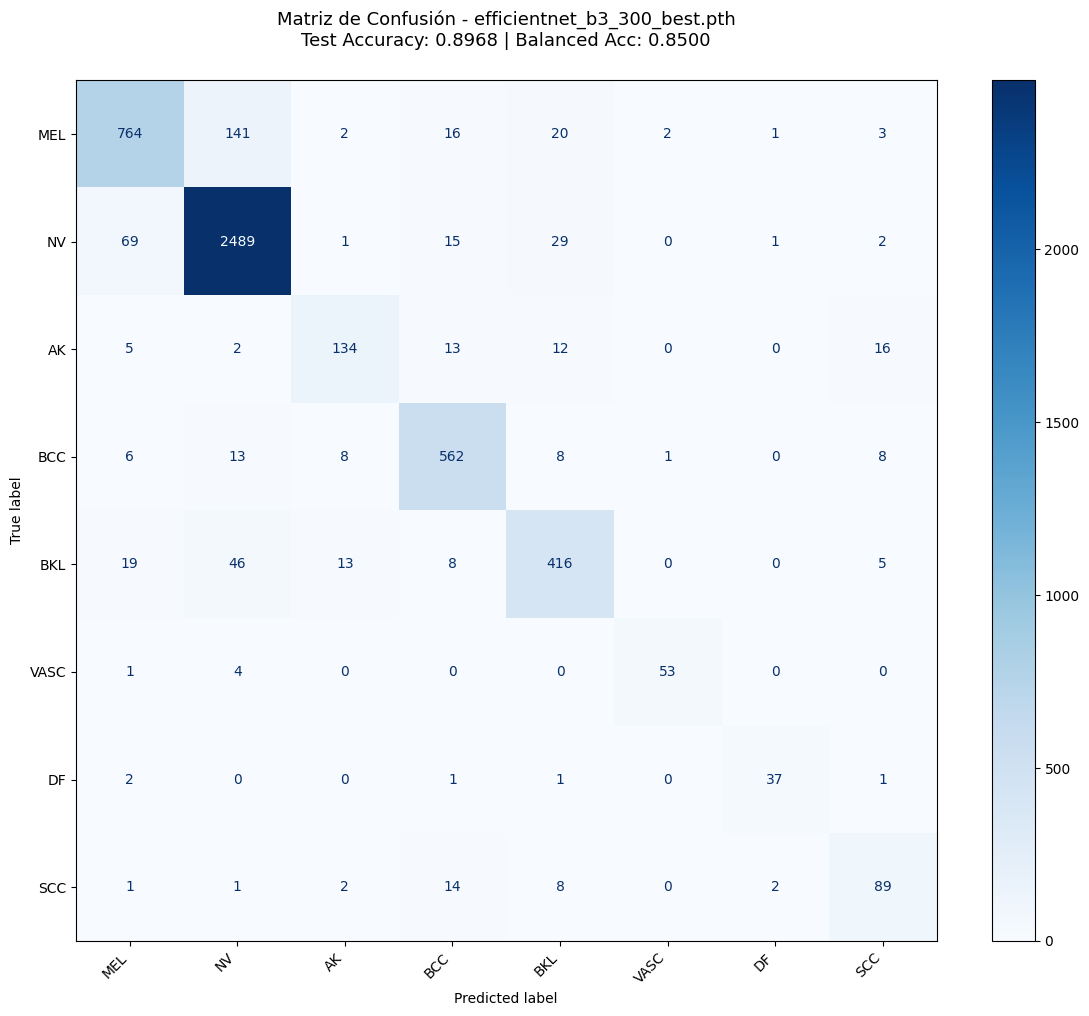

In [18]:
# ====================== CONFUSION MATRIX (Improved) ======================

unique_classes = sorted(set(all_labels))
class_names = [id2label[i] for i in unique_classes]

cm = confusion_matrix(all_labels, all_preds, labels=unique_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap='Blues', colorbar=True, values_format='.0f')

# Improve readability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title(f'Matriz de Confusión - {best_model_path}\n'
          f'Test Accuracy: {(all_preds == all_labels).mean():.4f} | '
          f'Balanced Acc: {balanced_accuracy_score(all_labels, all_preds):.4f}', 
          fontsize=13, pad=25)

plt.tight_layout()
plt.show()